In [14]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go



In [3]:
df = pd.read_csv("hospital_patient_treatment_dataset.csv")
df.head()


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43


In [4]:
df = pd.read_csv("hospital_patient_treatment_dataset.csv")
df.head()


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43


In [5]:
df.isnull().sum()
df.duplicated().sum()
df.nunique()
df.dtypes
df.describe(include="all")
df.skew(numeric_only=True)



Age                     0.048317
Treatment Cost         -0.002652
Hospital Stay (Days)   -0.107107
Recovery Score         -0.116936
dtype: float64

In [6]:
df.isnull().sum()
df.duplicated().sum()
df.nunique()
df.dtypes
df.describe(include="all")
df.skew(numeric_only=True)


Age                     0.048317
Treatment Cost         -0.002652
Hospital Stay (Days)   -0.107107
Recovery Score         -0.116936
dtype: float64

In [7]:
hospital_df = df.copy()

hospital_df = hospital_df.drop_duplicates()

hospital_df.isnull().sum()
hospital_df.dtypes
hospital_df.columns.tolist()


['Patient ID',
 'Department',
 'Treatment Type',
 'Doctor Name',
 'Gender',
 'Age',
 'Treatment Cost',
 'Hospital Stay (Days)',
 'Recovery Score']

In [8]:
hospital_df["Treatment Cost"] = pd.to_numeric(hospital_df["Treatment Cost"], errors="coerce")
hospital_df["Hospital Stay (Days)"] = pd.to_numeric(hospital_df["Hospital Stay (Days)"], errors="coerce")
hospital_df["Recovery Score"] = pd.to_numeric(hospital_df["Recovery Score"], errors="coerce")


In [9]:
hospital_df = hospital_df.dropna(
    subset=[
        "Department",
        "Treatment Type",
        "Doctor Name",
        "Gender",
        "Age",
        "Treatment Cost",
        "Hospital Stay (Days)",
        "Recovery Score"
    ]
)

hospital_df.isnull().sum()


Patient ID              0
Department              0
Treatment Type          0
Doctor Name             0
Gender                  0
Age                     0
Treatment Cost          0
Hospital Stay (Days)    0
Recovery Score          0
dtype: int64

In [10]:
hospital_df["Cost_Category"] = pd.cut(
    hospital_df["Treatment Cost"],
    bins=[0, 50000, 100000, 150000],
    labels=["Low", "Medium", "High"]
)

hospital_df["Age_Group"] = pd.cut(
    hospital_df["Age"],
    bins=[0, 18, 40, 60, 100],
    labels=["Child", "Adult", "Middle Age", "Senior"]
)

hospital_df["Recovery_Level"] = pd.cut(
    hospital_df["Recovery Score"],
    bins=[0, 50, 75, 100],
    labels=["Poor", "Moderate", "Excellent"]
)

hospital_df.head()


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score,Cost_Category,Age_Group,Recovery_Level
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82,Medium,Child,Excellent
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42,Low,Middle Age,Poor
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72,Low,Senior,Moderate
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50,High,Adult,Poor
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43,High,Child,Poor


In [11]:
hospital_df.info()
hospital_df.describe()
hospital_df.head()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Patient ID            200 non-null    str     
 1   Department            200 non-null    str     
 2   Treatment Type        200 non-null    str     
 3   Doctor Name           200 non-null    str     
 4   Gender                200 non-null    str     
 5   Age                   200 non-null    int64   
 6   Treatment Cost        200 non-null    float64 
 7   Hospital Stay (Days)  200 non-null    int64   
 8   Recovery Score        200 non-null    int64   
 9   Cost_Category         200 non-null    category
 10  Age_Group             200 non-null    category
 11  Recovery_Level        200 non-null    category
dtypes: category(3), float64(1), int64(3), str(5)
memory usage: 23.3 KB


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score,Cost_Category,Age_Group,Recovery_Level
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82,Medium,Child,Excellent
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42,Low,Middle Age,Poor
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72,Low,Senior,Moderate
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50,High,Adult,Poor
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43,High,Child,Poor


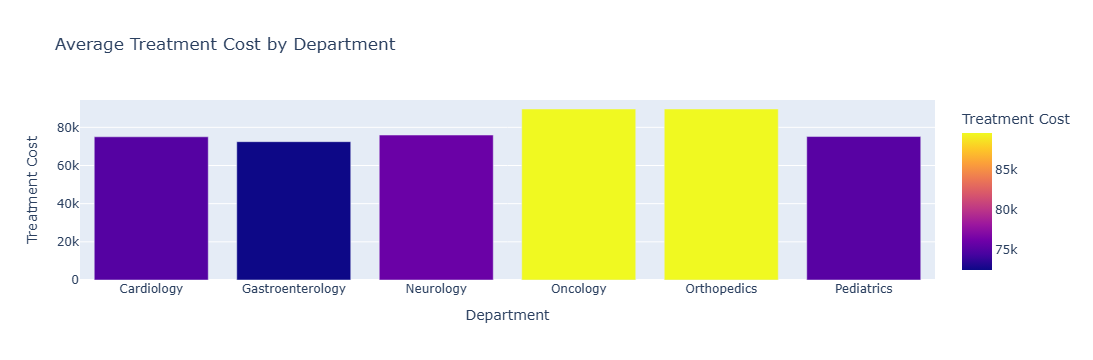

In [12]:
dept_cost = hospital_df.groupby("Department", as_index=False)["Treatment Cost"].mean()

fig = px.bar(
    dept_cost,
    x="Department",
    y="Treatment Cost",
    color="Treatment Cost",
    title="Average Treatment Cost by Department"
)
fig.show()


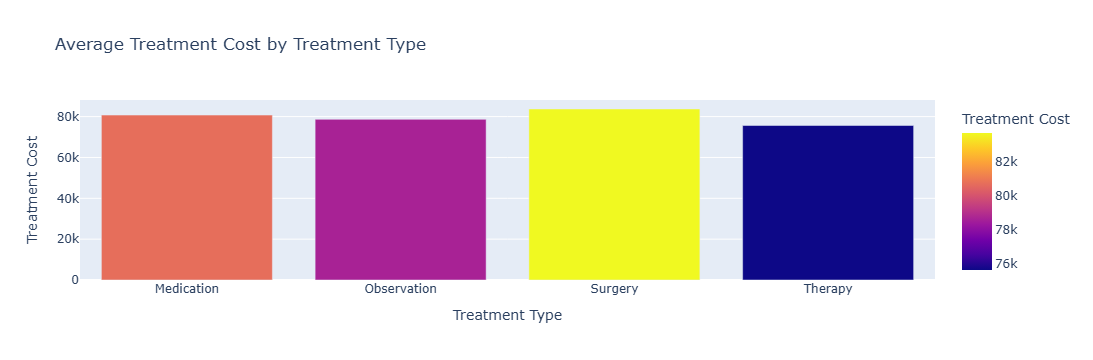

In [13]:
treatment_cost = hospital_df.groupby("Treatment Type", as_index=False)["Treatment Cost"].mean()

fig = px.bar(
    treatment_cost,
    x="Treatment Type",
    y="Treatment Cost",
    color="Treatment Cost",
    title="Average Treatment Cost by Treatment Type"
)
fig.show()


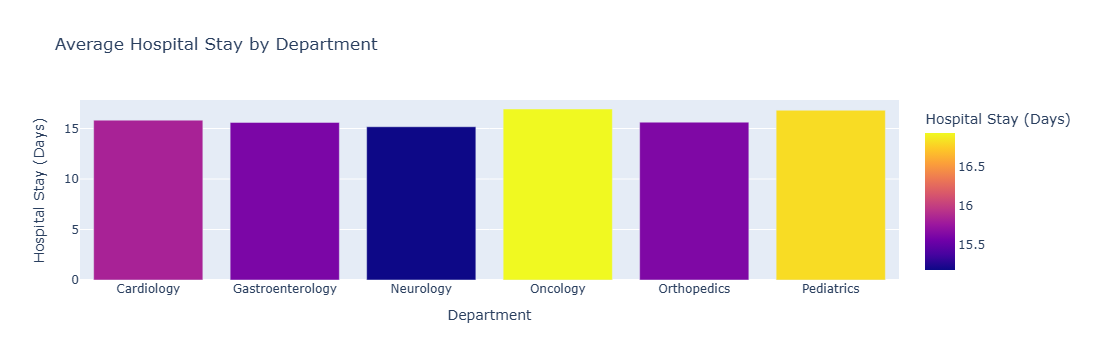

In [15]:
dept_stay = hospital_df.groupby("Department", as_index=False)["Hospital Stay (Days)"].mean()

fig = px.bar(
    dept_stay,
    x="Department",
    y="Hospital Stay (Days)",
    color="Hospital Stay (Days)",
    title="Average Hospital Stay by Department"
)
fig.show()


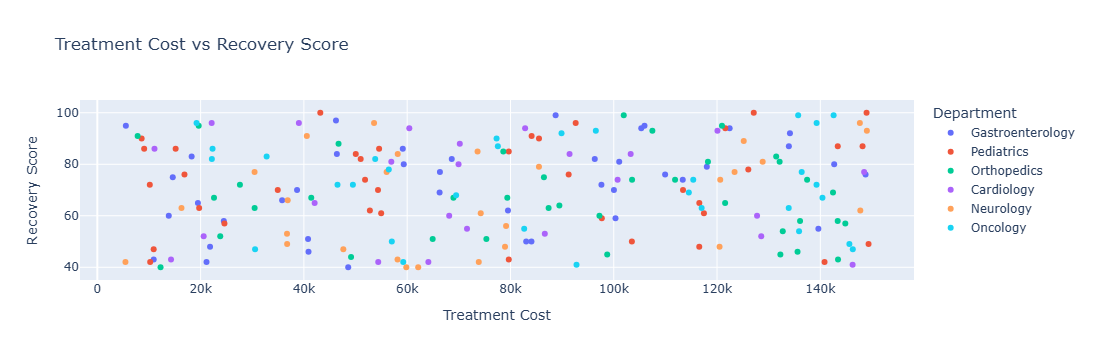

In [16]:
fig = px.scatter(
    hospital_df,
    x="Treatment Cost",
    y="Recovery Score",
    color="Department",
    hover_data=["Treatment Type", "Doctor Name"],
    title="Treatment Cost vs Recovery Score"
)
fig.show()


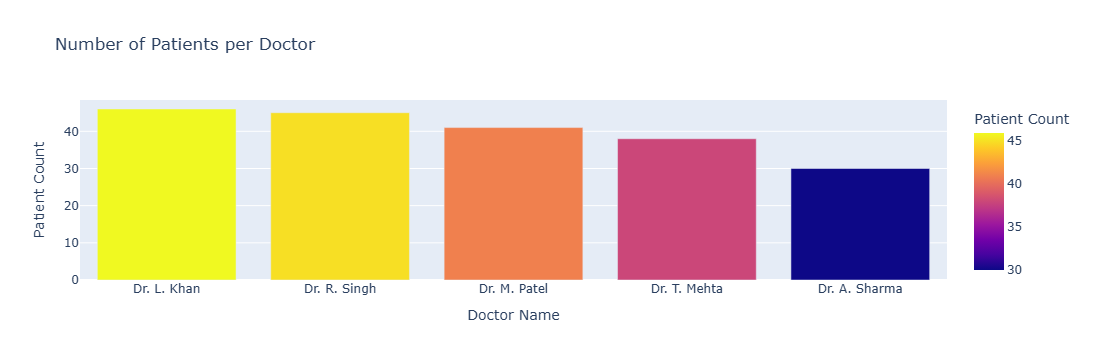

In [17]:
doctor_volume = hospital_df["Doctor Name"].value_counts().reset_index()
doctor_volume.columns = ["Doctor Name", "Patient Count"]

fig = px.bar(
    doctor_volume,
    x="Doctor Name",
    y="Patient Count",
    color="Patient Count",
    title="Number of Patients per Doctor"
)
fig.show()


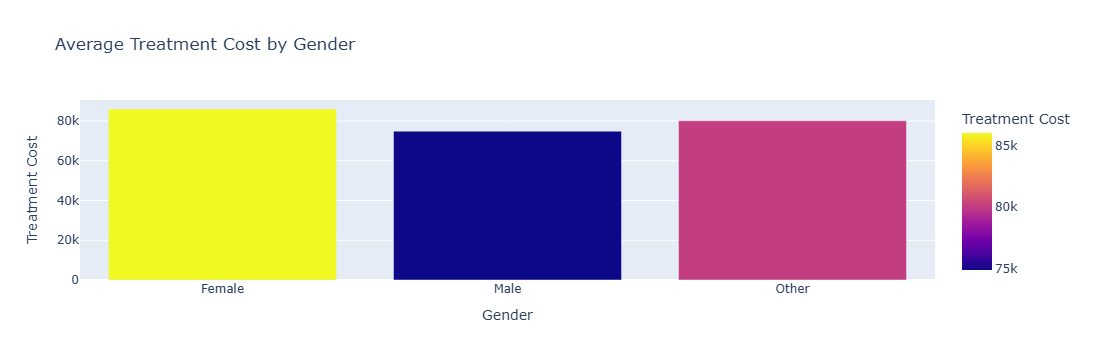

In [18]:
gender_cost = hospital_df.groupby("Gender", as_index=False)["Treatment Cost"].mean()

fig = px.bar(
    gender_cost,
    x="Gender",
    y="Treatment Cost",
    color="Treatment Cost",
    title="Average Treatment Cost by Gender"
)
fig.show()


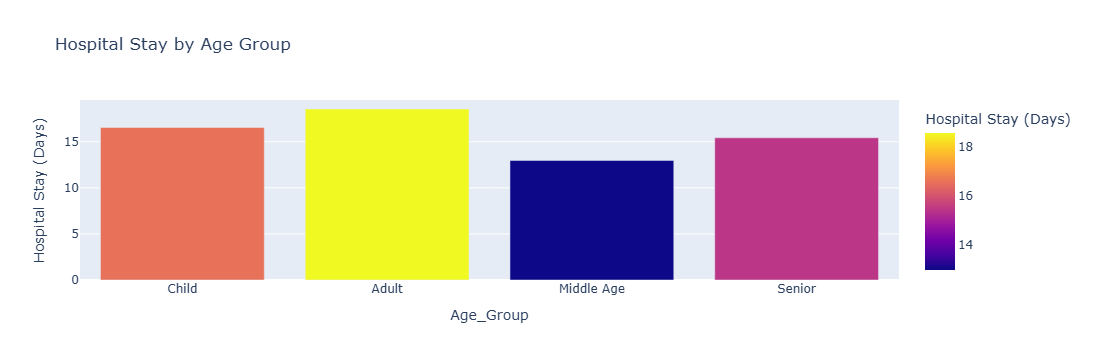

In [19]:
age_stay = hospital_df.groupby("Age_Group", as_index=False)["Hospital Stay (Days)"].mean()

fig = px.bar(
    age_stay,
    x="Age_Group",
    y="Hospital Stay (Days)",
    color="Hospital Stay (Days)",
    title="Hospital Stay by Age Group"
)
fig.show()


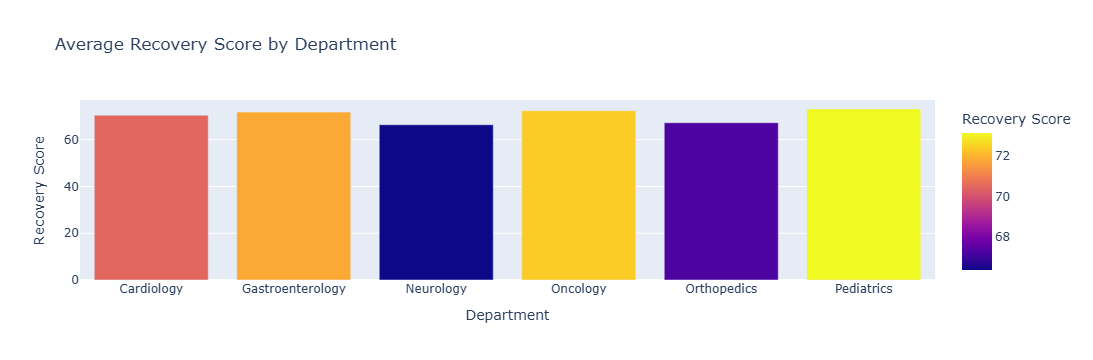

In [20]:
dept_recovery = hospital_df.groupby("Department", as_index=False)["Recovery Score"].mean()

fig = px.bar(
    dept_recovery,
    x="Department",
    y="Recovery Score",
    color="Recovery Score",
    title="Average Recovery Score by Department"
)
fig.show()


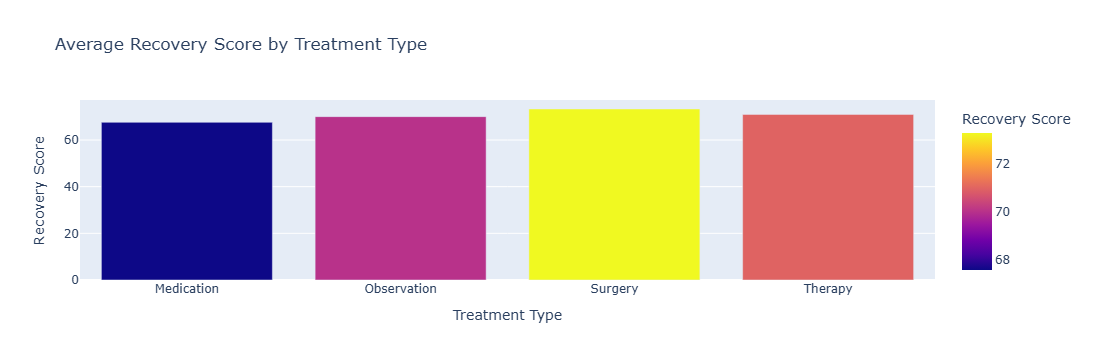

In [21]:
treatment_recovery = hospital_df.groupby("Treatment Type", as_index=False)["Recovery Score"].mean()

fig = px.bar(
    treatment_recovery,
    x="Treatment Type",
    y="Recovery Score",
    color="Recovery Score",
    title="Average Recovery Score by Treatment Type"
)
fig.show()


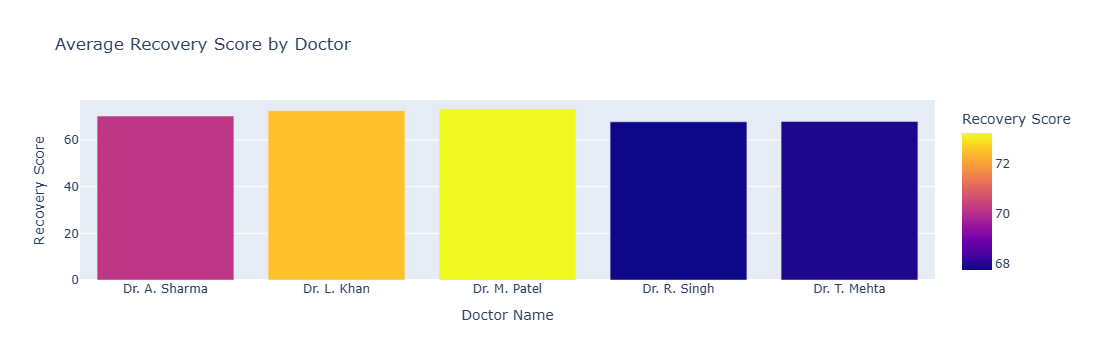

In [22]:
doctor_recovery = hospital_df.groupby("Doctor Name", as_index=False)["Recovery Score"].mean()

fig = px.bar(
    doctor_recovery,
    x="Doctor Name",
    y="Recovery Score",
    color="Recovery Score",
    title="Average Recovery Score by Doctor"
)
fig.show()
